# Cohort Analysis & Customer Retention

## Overview
This notebook performs a cohort analysis to track customer retention over time. By grouping customers based on their first purchase month (cohort), we can observe how many of them return to make subsequent purchases in the following months.

## Objectives
1.  **Data Extraction:** Query the database to identify customer cohorts and their monthly activity.
2.  **Data Transformation:** Pivot the data to create a cohort matrix.
3.  **Retention Calculation:** Calculate retention rates as a percentage of the original cohort size.
4.  **Visualization:** Create a heatmap to visualize retention trends.

In [13]:
import pandas as pd
import sqlite3
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

In [14]:
# Connect to the SQLite database
conn = sqlite3.connect('olist.db')

## 1. Execute Cohort Query
We execute a SQL query that:
1.  Identifies the first purchase month for each customer (Cohort Month).
2.  Tracks all purchase months for each customer.
3.  Calculates the time difference (in months) between the first purchase and subsequent purchases.
4.  Counts the number of active customers for each cohort in each subsequent month.

In [15]:
with open('queries/cohort_retention.sql', 'r') as f:
    query = f.read()

df_cohort = pd.read_sql(query, conn)
df_cohort.head()

,cohort_month,month_diff,active_customers
0,2016-09-01,0,1
1,2016-10-01,0,262
2,2016-10-01,6,1
3,2016-10-01,9,1
4,2016-10-01,11,1


## 2. Pivot Data for Heatmap
We transform the data into a matrix format where:
-   **Rows:** Cohort Month (when the customer first bought).
-   **Columns:** Month Difference (0, 1, 2... months since first purchase).
-   **Values:** Number of active customers.

We also fill `NaN` values with 0, as `NaN` implies no purchases were made by that cohort in that month.

In [16]:
cohort_pivot = df_cohort.pivot_table(index='cohort_month', columns='month_diff', values='active_customers')
cohort_pivot = cohort_pivot.fillna(0)
cohort_pivot.head()

month_diff,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,19,20
cohort_month,,,,,,,,,,,,,,,,,,,,
2016-09-01,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2016-10-01,262.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,2.0,2.0
2016-12-01,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2017-01-01,717.0,2.0,2.0,1.0,3.0,1.0,3.0,1.0,1.0,0.0,3.0,1.0,5.0,3.0,1.0,1.0,2.0,3.0,1.0,0.0
2017-02-01,1628.0,3.0,5.0,2.0,7.0,2.0,4.0,3.0,2.0,3.0,2.0,5.0,2.0,3.0,2.0,1.0,1.0,3.0,0.0,0.0


## 3. Calculate Retention Rate
To compare cohorts of different sizes, we calculate the retention rate.
Retention Rate = (Active Customers in Month X) / (Initial Cohort Size in Month 0)

In [17]:
cohort_size = cohort_pivot.iloc[:, 0]
retention_matrix = cohort_pivot.divide(cohort_size, axis=0)
retention_matrix.head()

month_diff,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,19,20
cohort_month,,,,,,,,,,,,,,,,,,,,
2016-09-01,1.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
2016-10-01,1.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.003817,0.000000,0.000000,0.003817,0.000000,0.003817,0.000000,0.003817,0.000000,0.003817,0.000000,0.003817,0.007634,0.007634
2016-12-01,1.0,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
2017-01-01,1.0,0.002789,0.002789,0.001395,0.004184,0.001395,0.004184,0.001395,0.001395,0.000000,0.004184,0.001395,0.006974,0.004184,0.001395,0.001395,0.002789,0.004184,0.001395,0.000000
2017-02-01,1.0,0.001843,0.003071,0.001229,0.004300,0.001229,0.002457,0.001843,0.001229,0.001843,0.001229,0.003071,0.001229,0.001843,0.001229,0.000614,0.000614,0.001843,0.000000,0.000000


## 4. Retention Heatmap
The heatmap visualizes customer retention.
-   **Darker colors** indicate higher retention.
-   **Month 0** is always 100% (the initial purchase).
-   We look for vertical patterns (seasonality) or horizontal patterns (cohort quality).

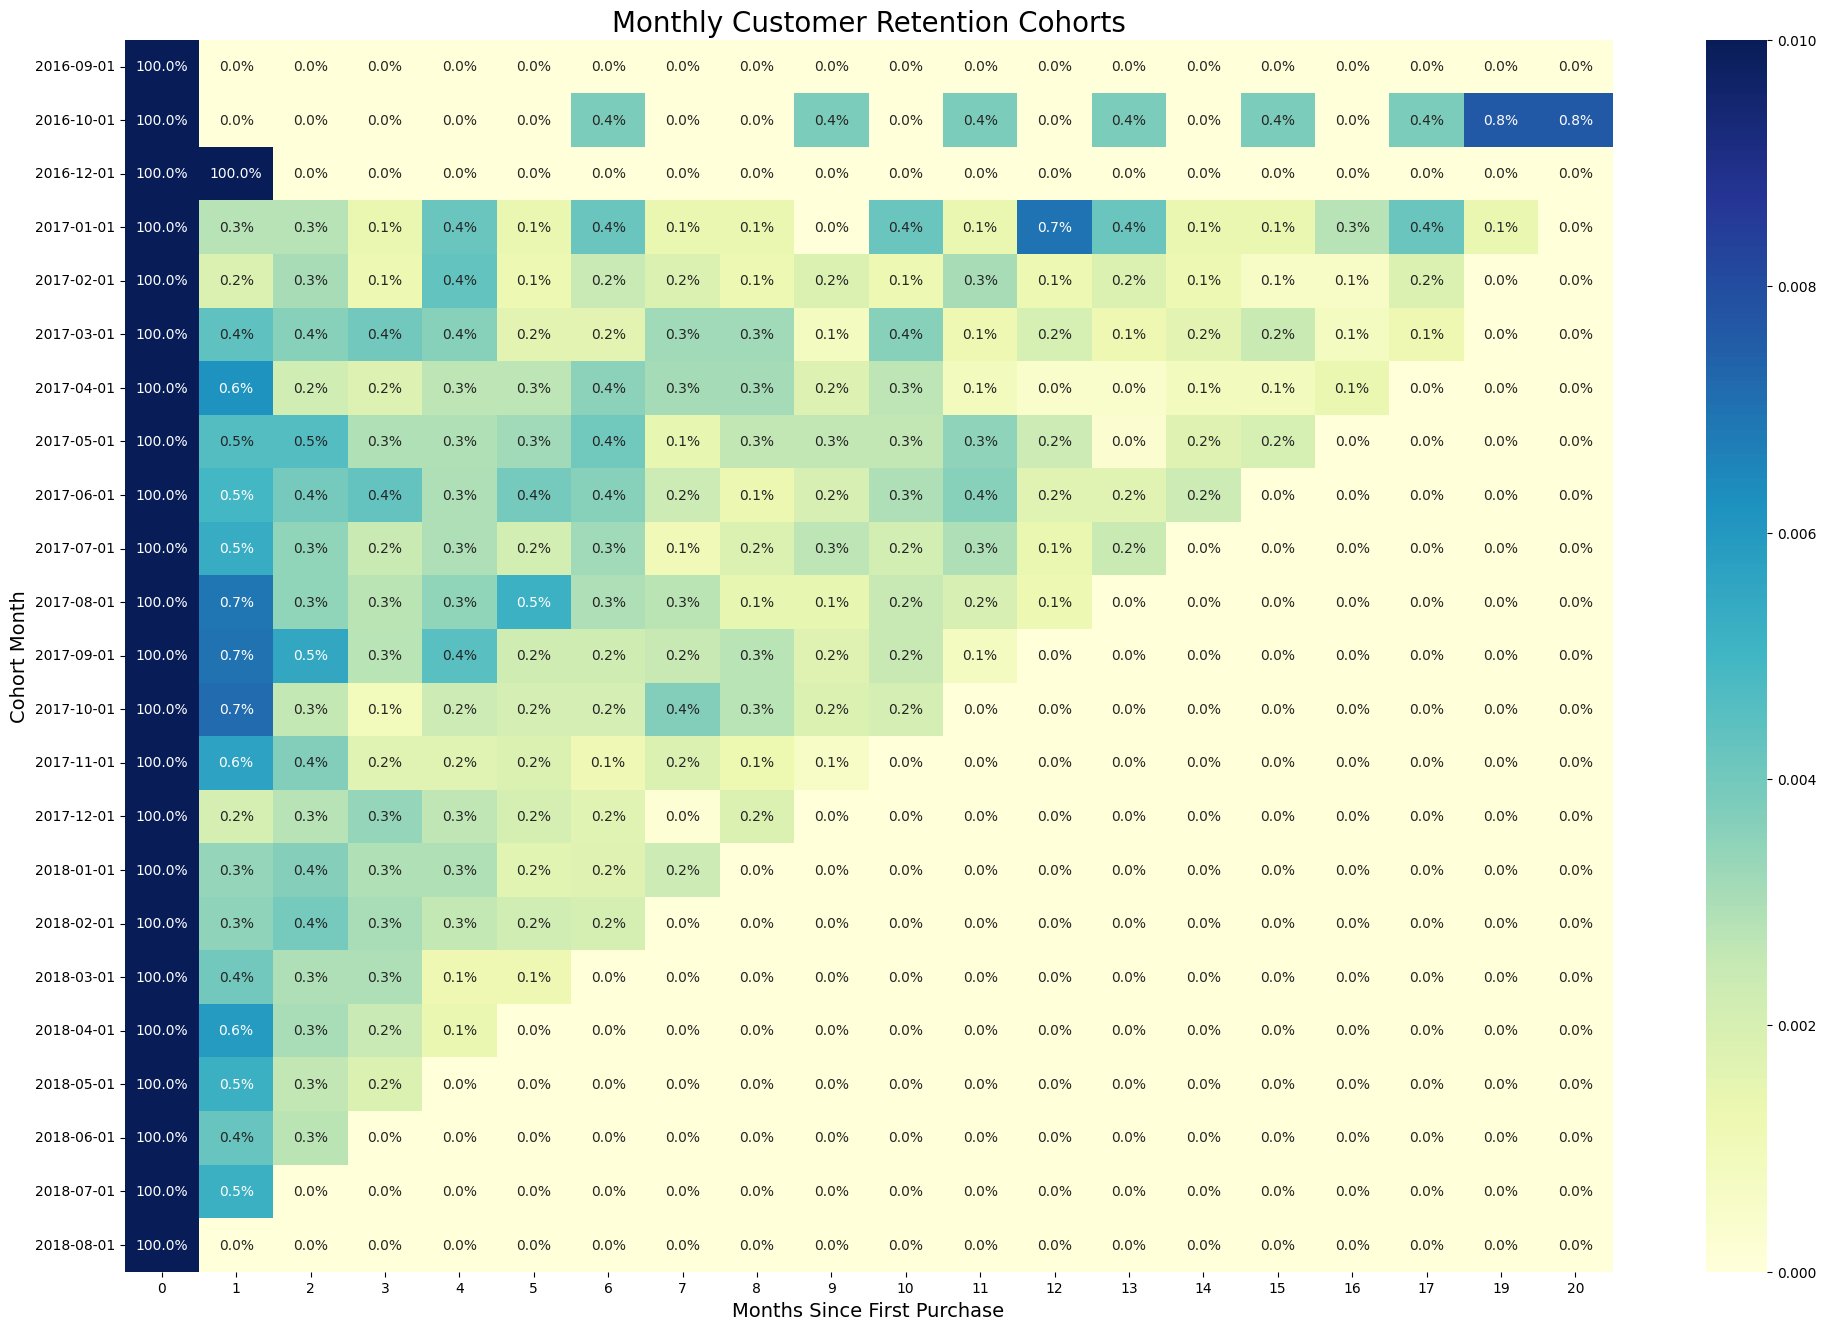

In [18]:
plt.figure(figsize=(24, 16))
sns.heatmap(retention_matrix, annot=True, fmt='.1%', cmap='YlGnBu', vmin=0.0, vmax=0.01)
plt.title('Monthly Customer Retention Cohorts', fontsize=20)
plt.ylabel('Cohort Month', fontsize=14)
plt.xlabel('Months Since First Purchase', fontsize=14)
plt.show()